# TGNNExplainer Case-Study Bars (`simulate_v1`)

This notebook is intentionally short.
All loading, target selection, and plotting logic lives in `I_explainer_benchmark/src/viz/simulate_case_study_notebook.py`.

Run all cells to:
- build the `simulate_v1` case-study state
- save the figures as PDF under `I_explainer_benchmark/notebooks/outputs/...`
- display the generated plots inline


In [1]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Could not locate repository root (missing .git in parents).")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


from I_explainer_benchmark.src.viz.simulate_case_study_notebook import CaseStudyConfig, SimulateCaseStudySession


In [ ]:
MODEL_NAME = "tgn"
EXTRA_PARTIAL_TARGETS = (61, 333, 711, 1020)

from I_explainer_benchmark.src.viz.simulate_case_study_bars import latest_run_file

RESULTS_ROOT = REPO_ROOT / "I_explainer_benchmark" / "resources" / "results" / "official_tgnnexplainer"
EXTRA_PRIMARY_RUN = latest_run_file(
    "simulate_v1",
    MODEL_NAME,
    RESULTS_ROOT,
    "tgnnexplainer",
    allow_missing=True,
)

config = CaseStudyConfig(
    dataset_name="simulate_v1",
    explainer_key="tgnnexplainer",
    model_by_dataset={"simulate_v1": MODEL_NAME, "simulate_v2": MODEL_NAME},
    save_single_view_plots=True,
    save_split_view_plots=True,
    save_formats=("pdf",),
)

session = SimulateCaseStudySession(config, repo_root=REPO_ROOT)
figures = session.build_default_figures(save=True)

if EXTRA_PRIMARY_RUN is not None:
    extra_config = CaseStudyConfig(
        dataset_name="simulate_v1",
        explainer_key="tgnnexplainer",
        model_by_dataset={"simulate_v1": MODEL_NAME, "simulate_v2": MODEL_NAME},
        primary_run_file=str(EXTRA_PRIMARY_RUN),
        partial_target_event_ids=EXTRA_PARTIAL_TARGETS,
        save_single_view_plots=True,
        save_split_view_plots=True,
        save_formats=("pdf",),
    )
    extra_session = SimulateCaseStudySession(extra_config, repo_root=REPO_ROOT)
    figures.extend(extra_session.build_default_figures(save=True))


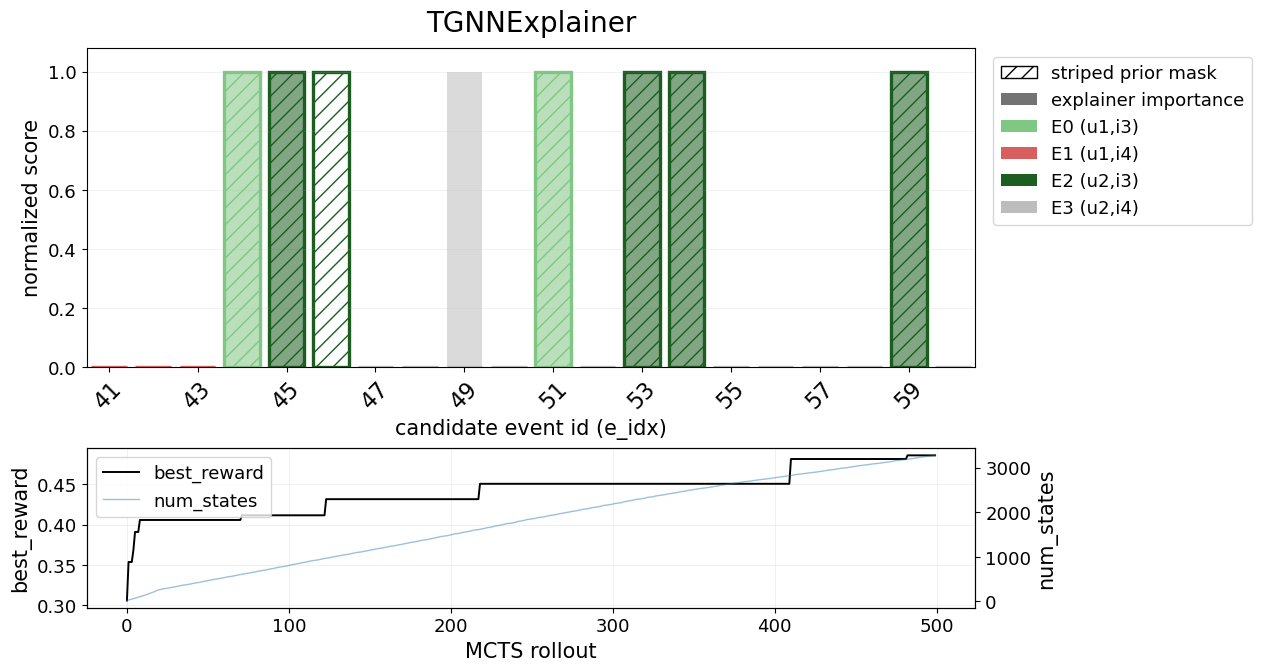

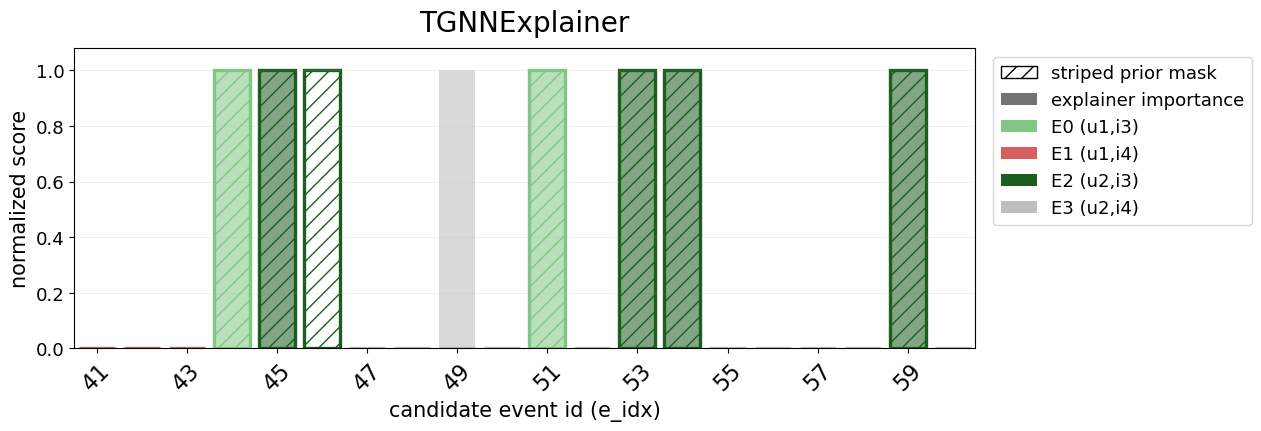

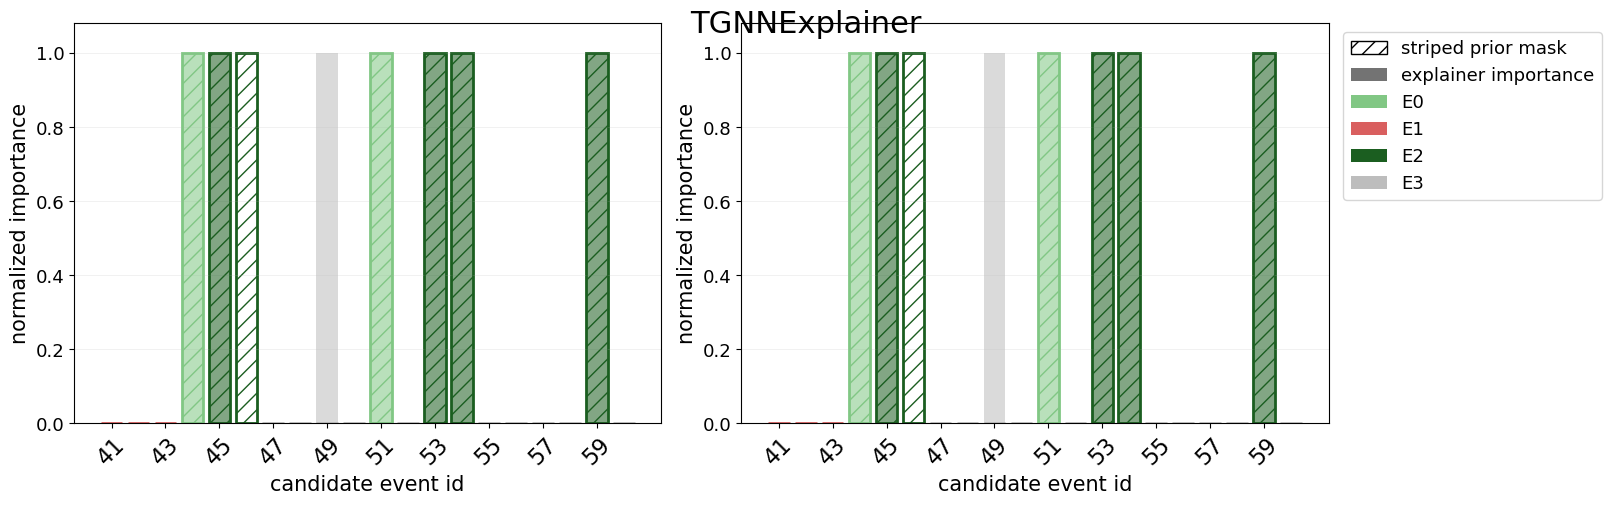

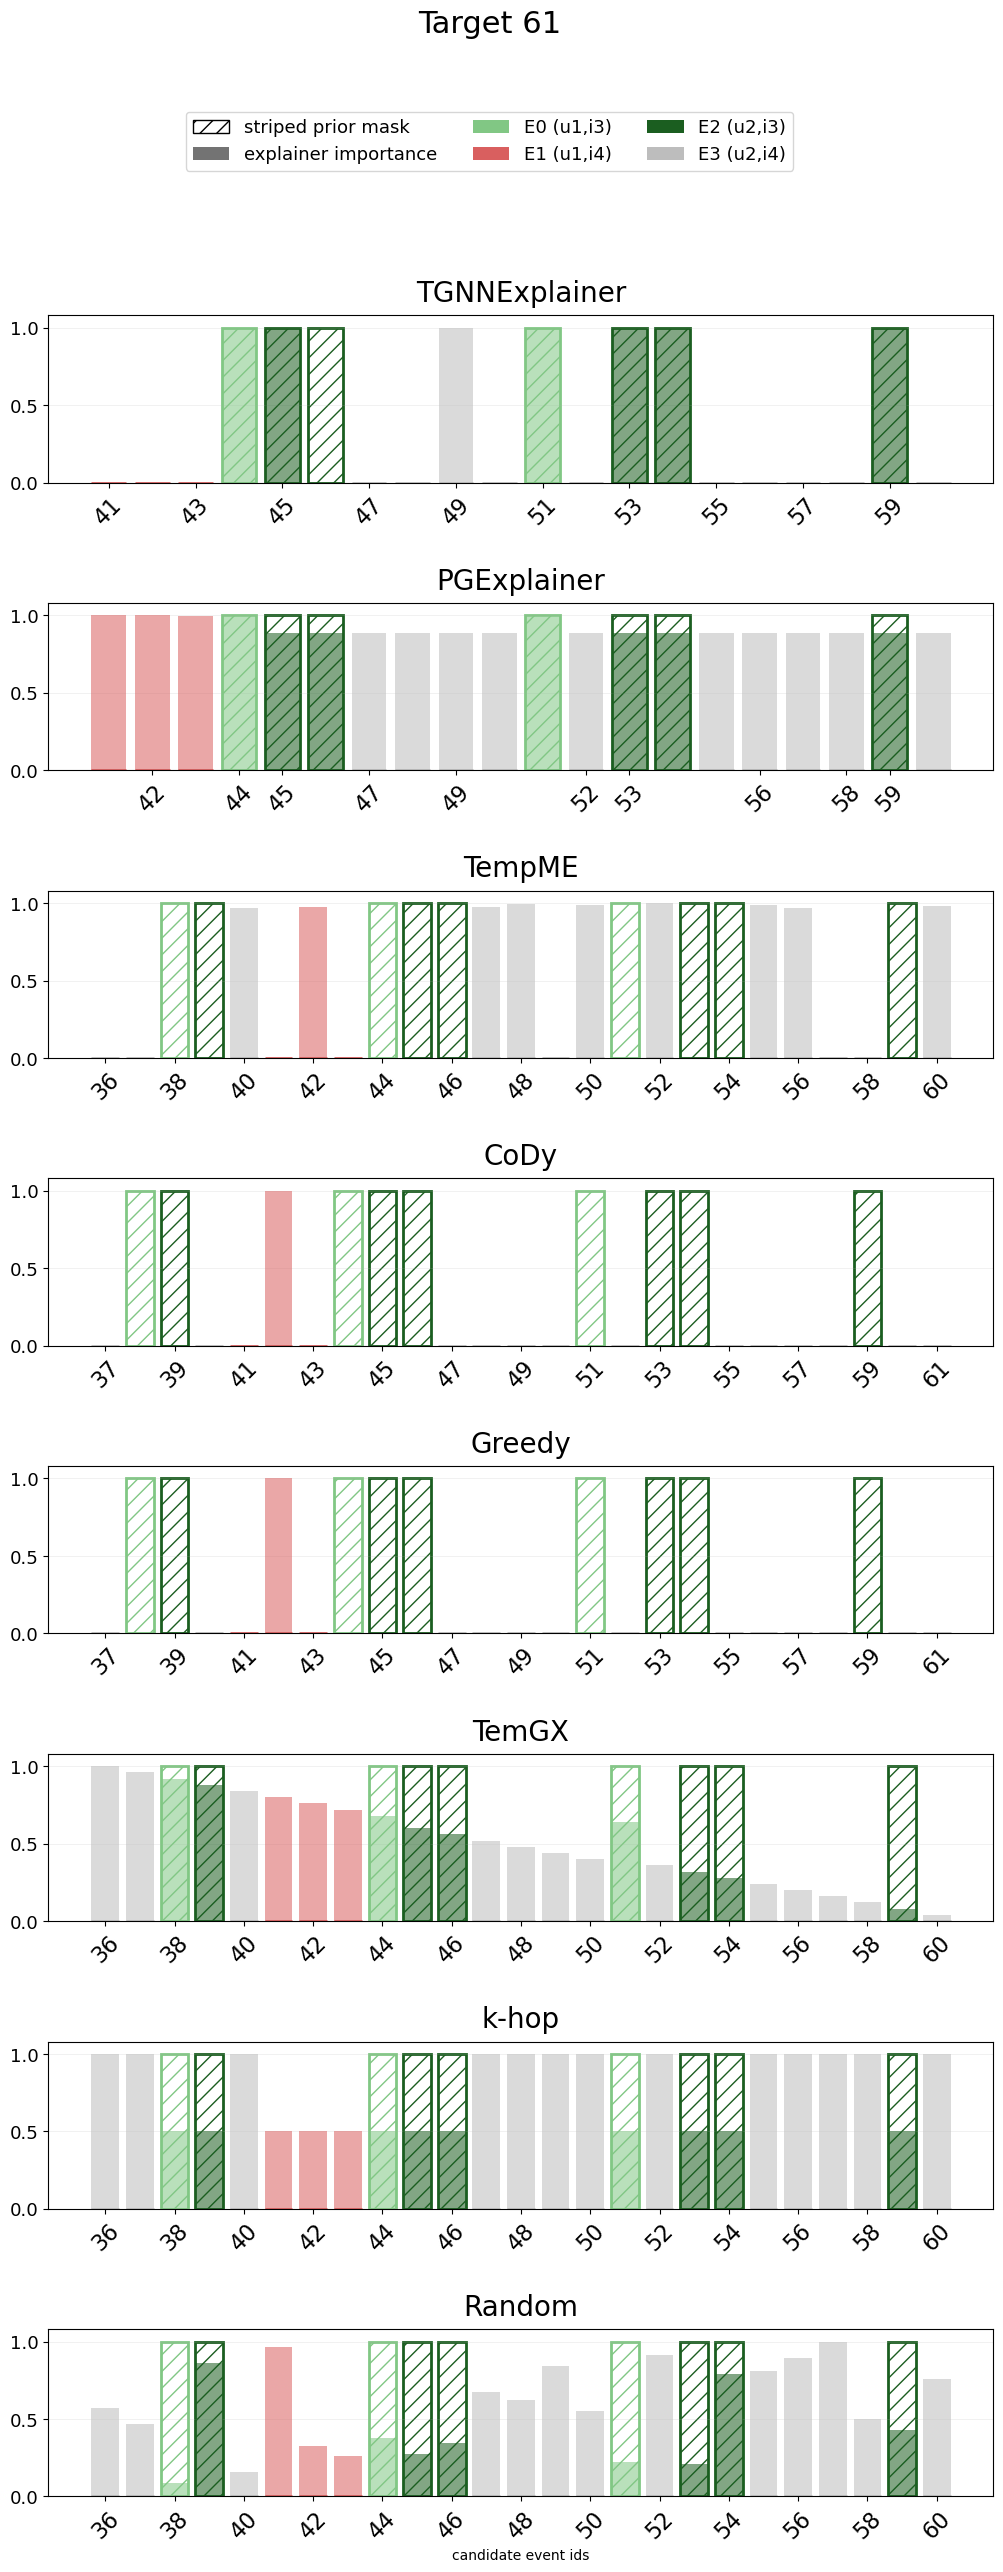

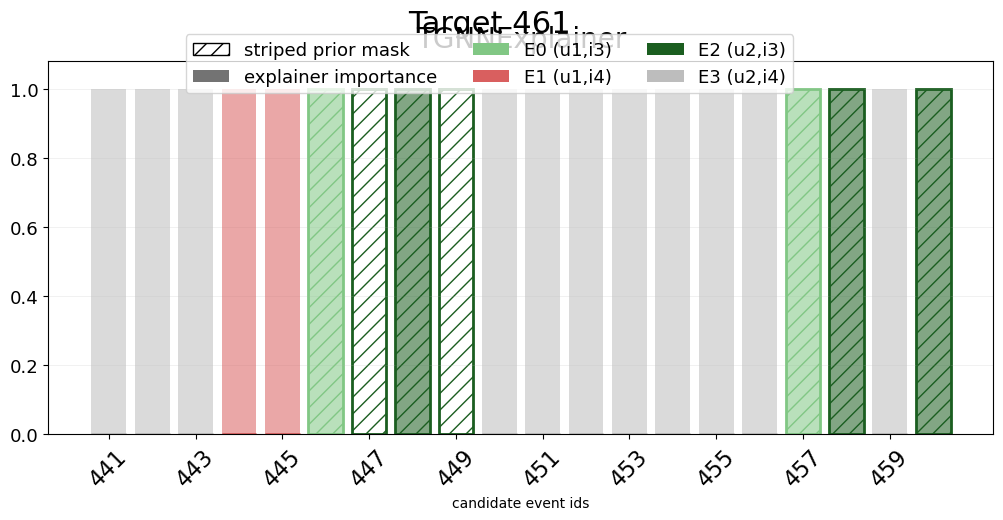

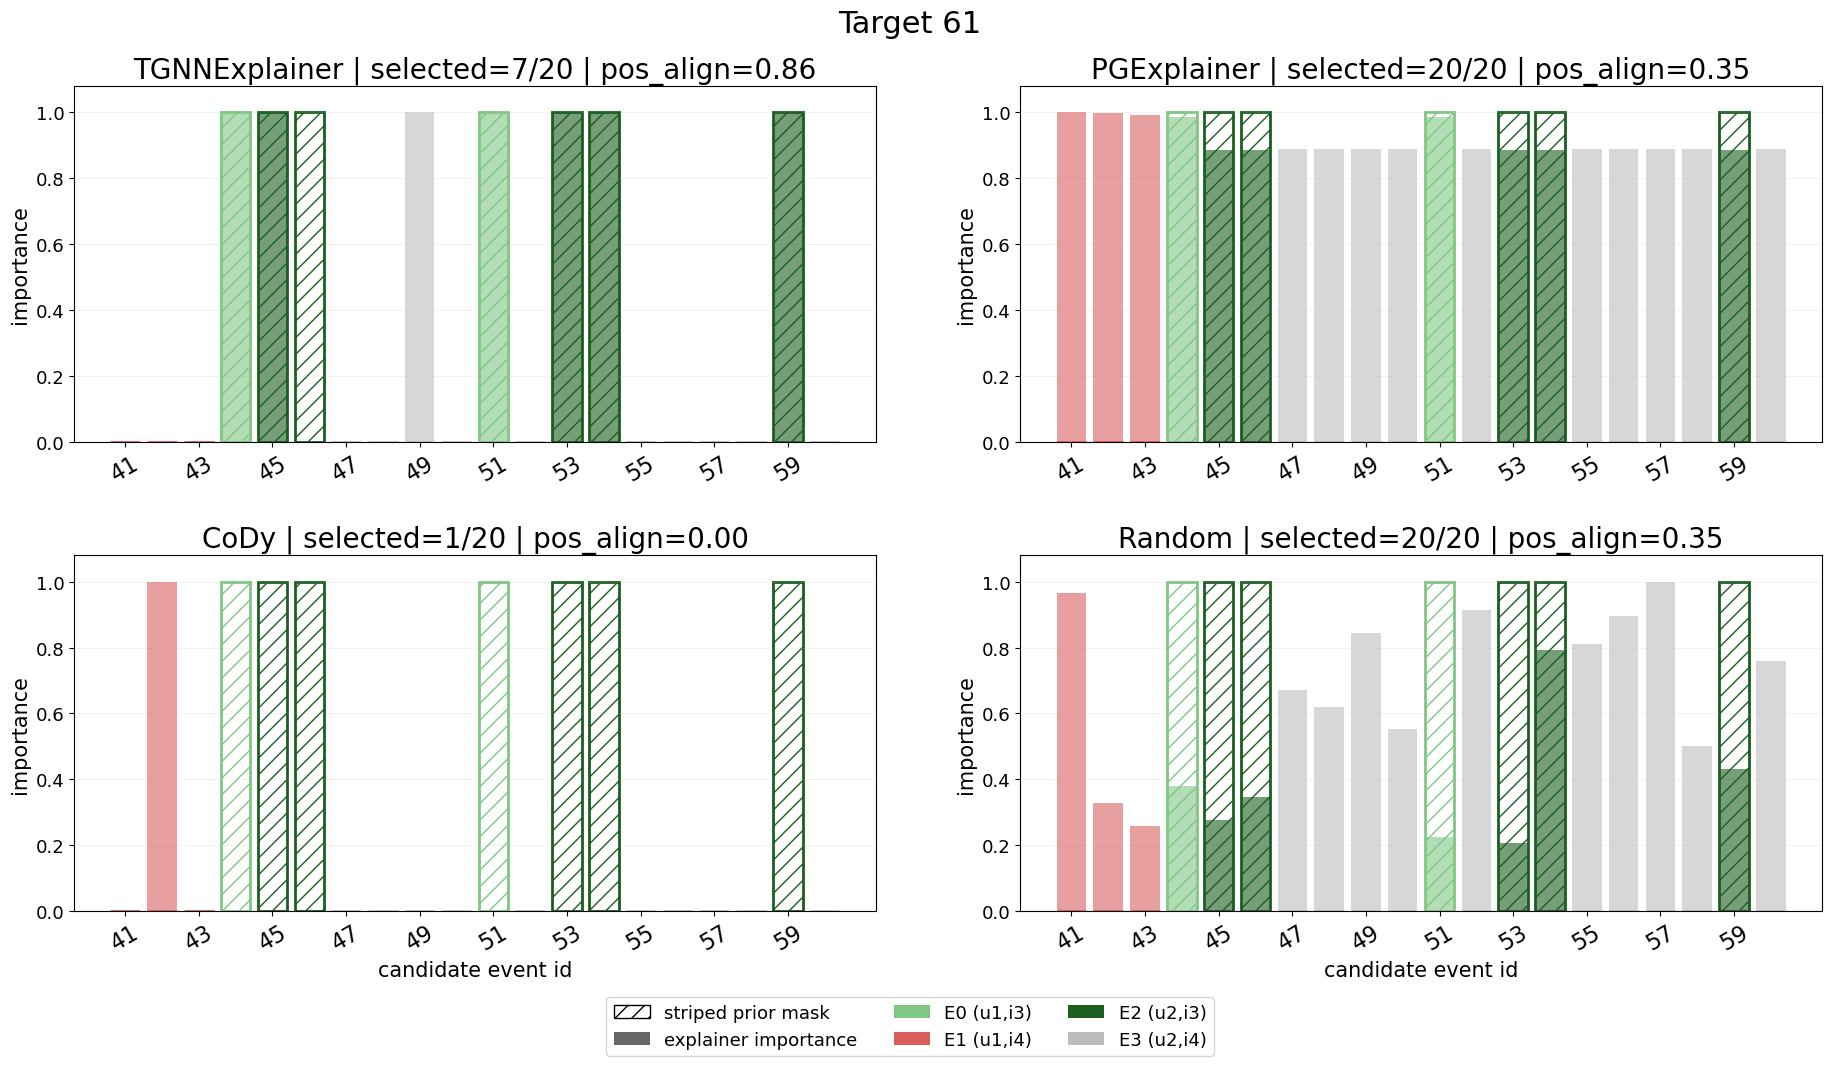

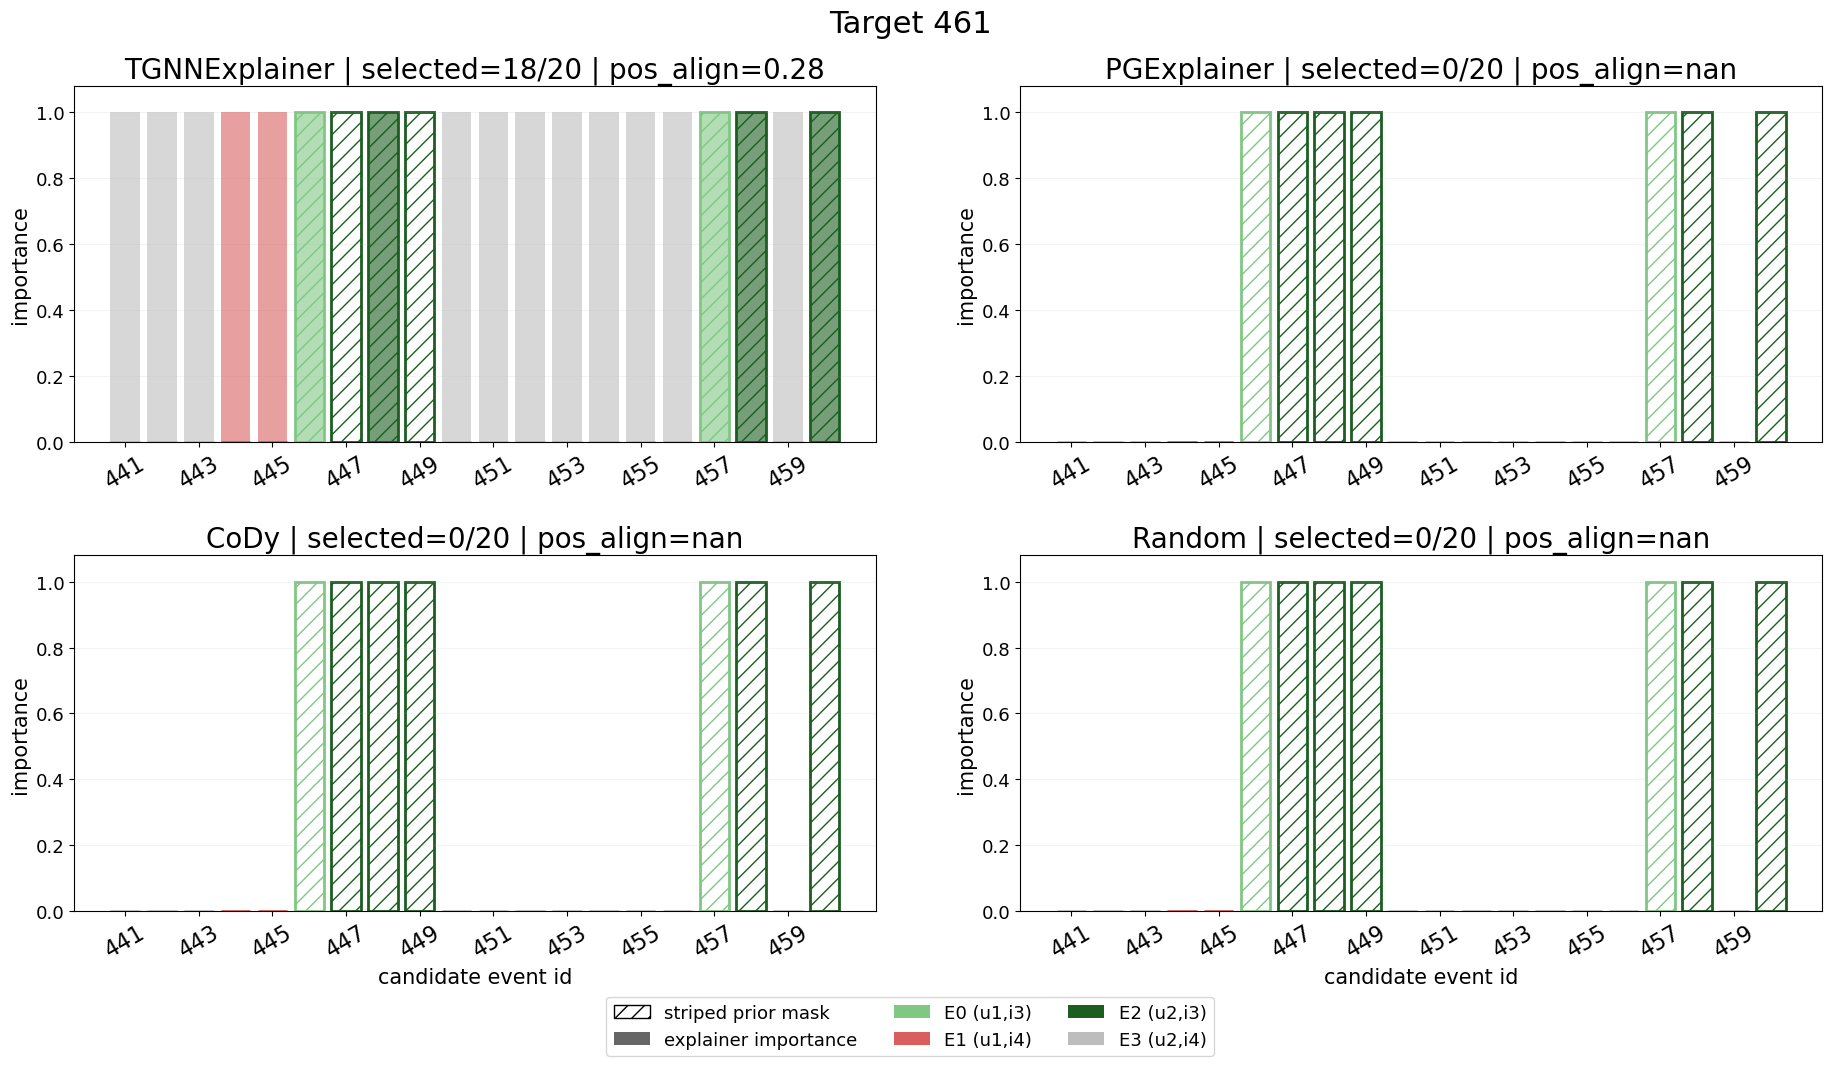

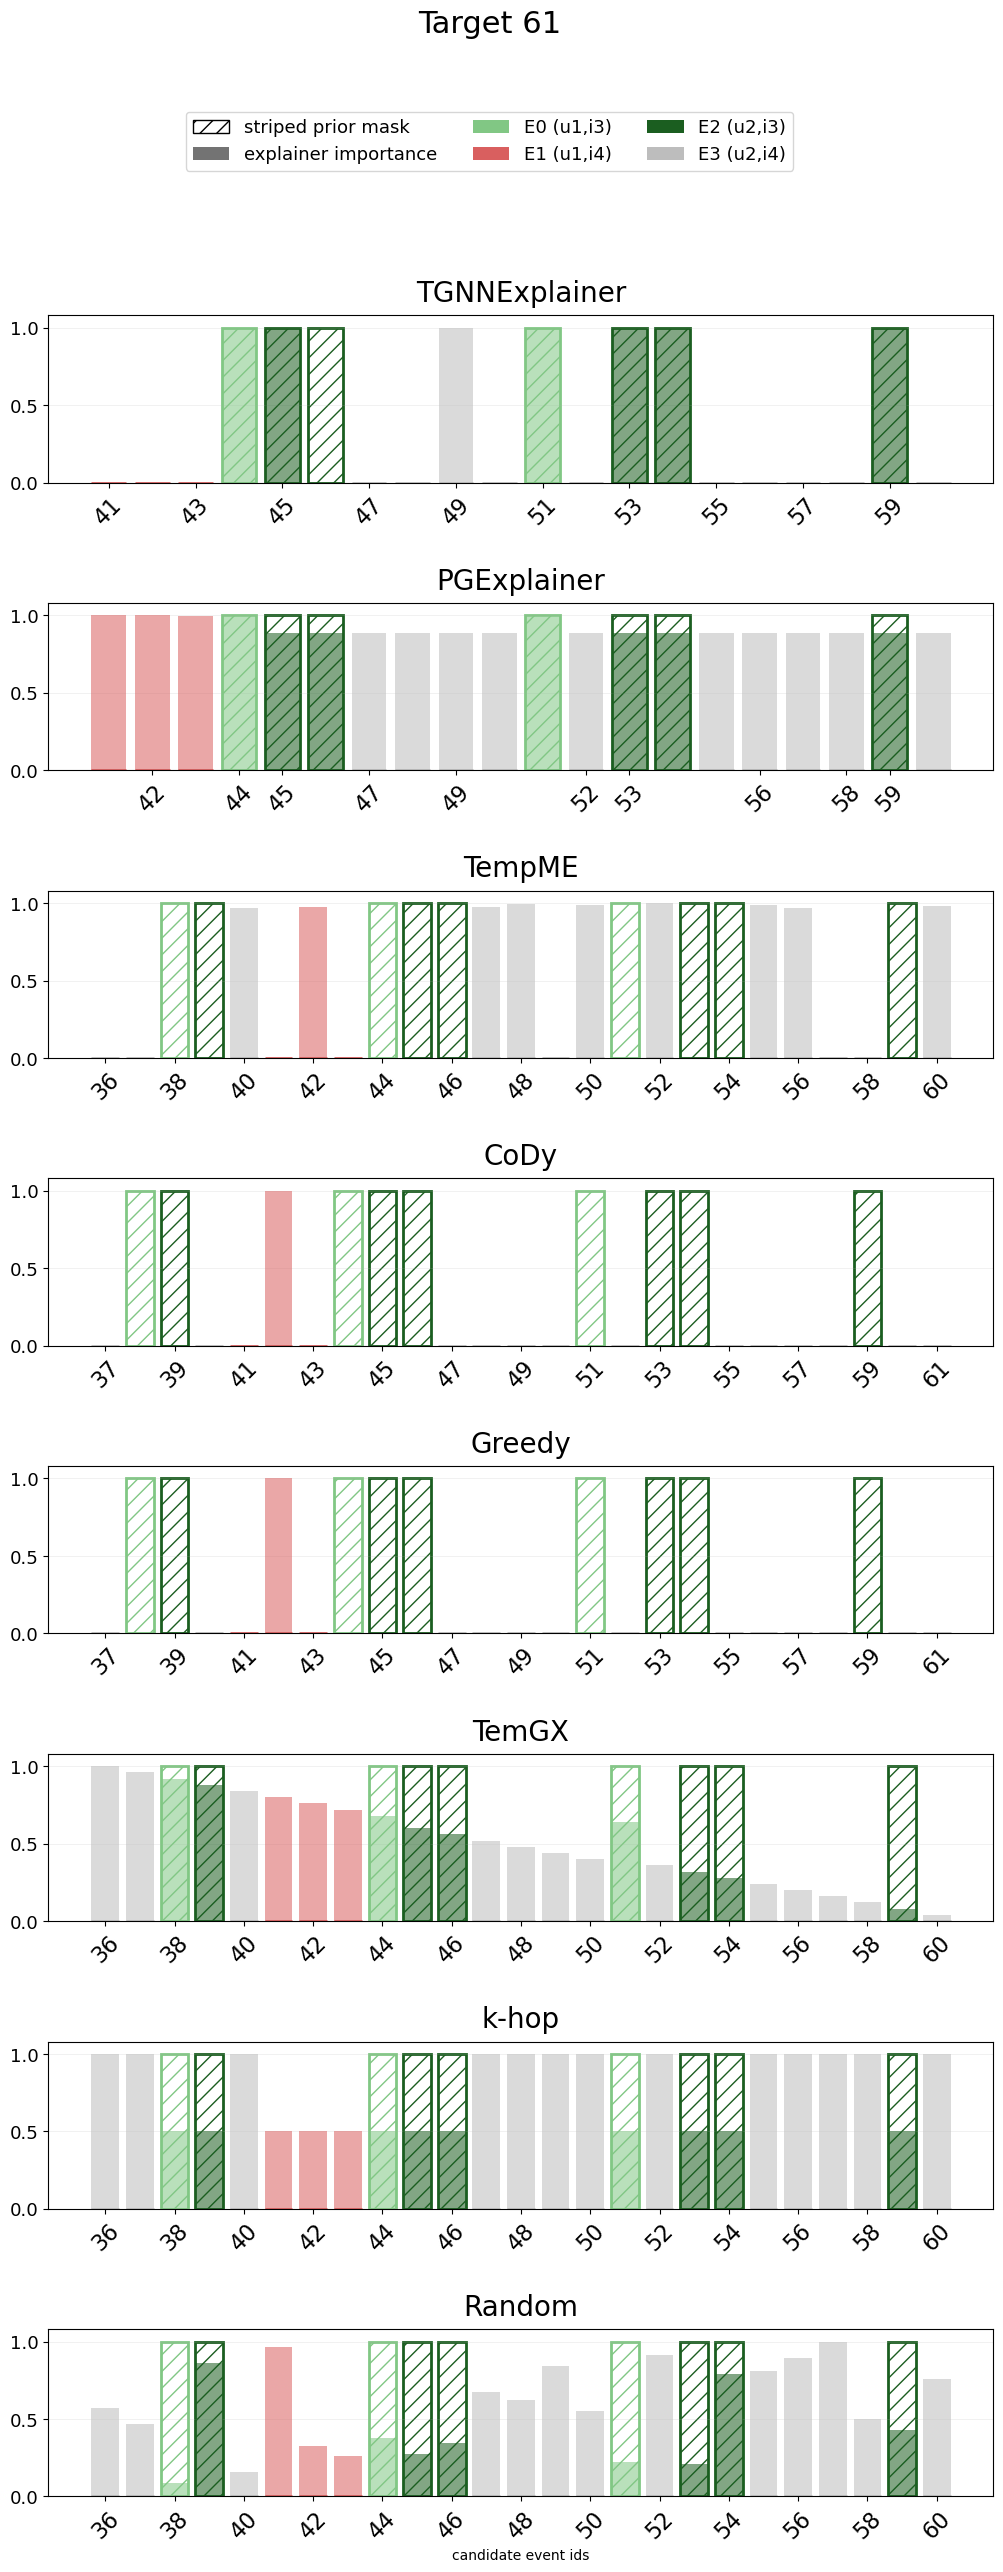

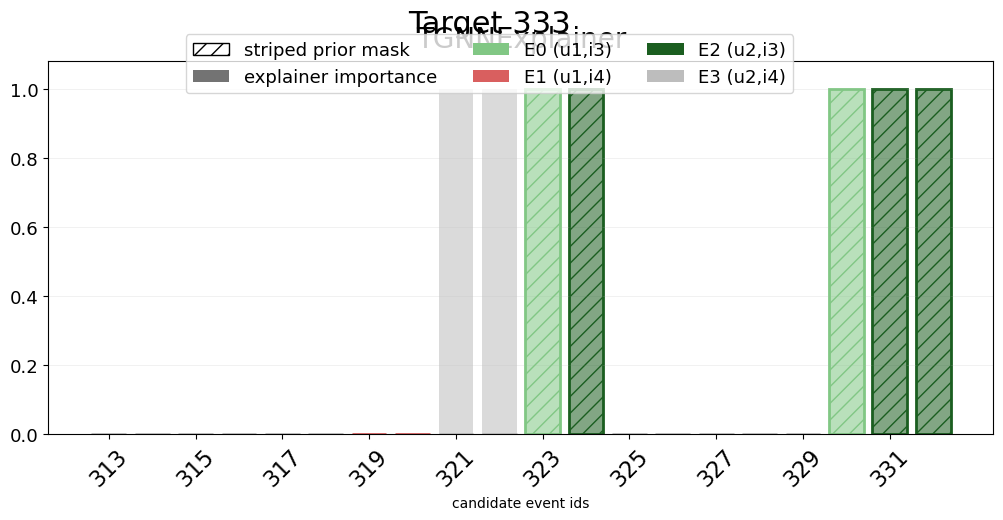

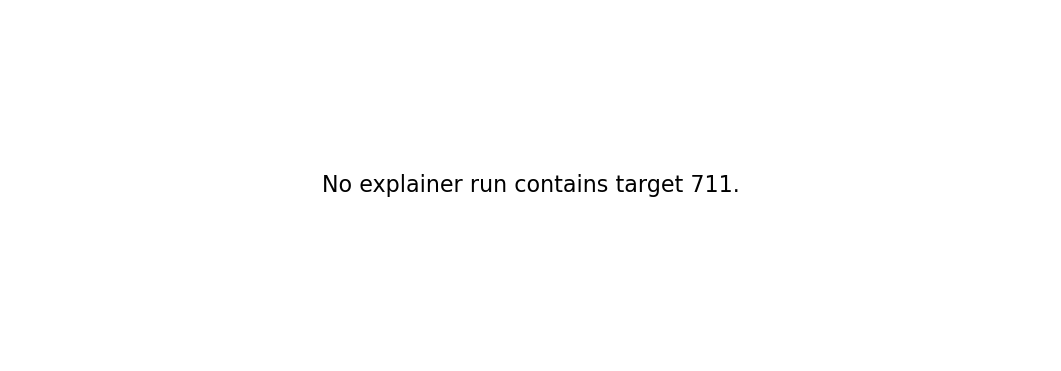

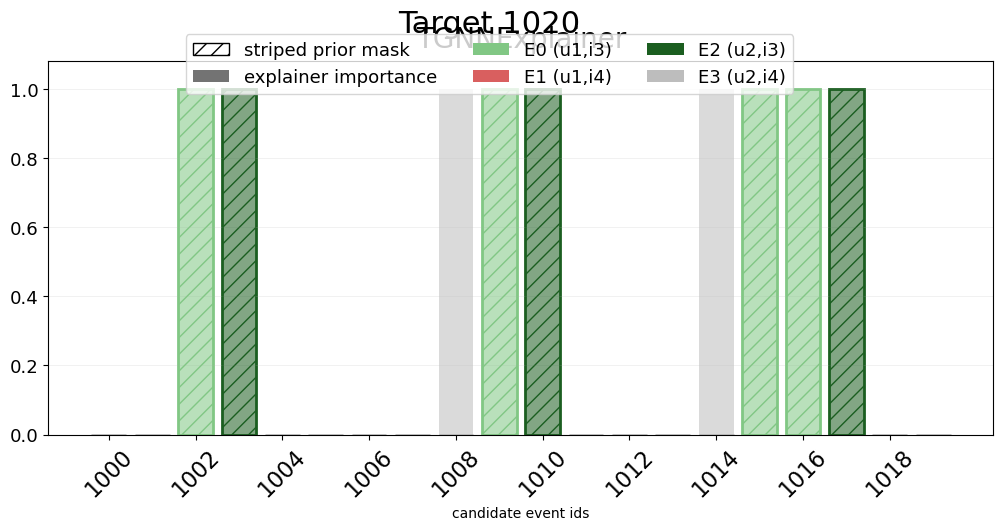

In [3]:
from IPython.display import display


for _, fig in figures:
    display(fig)
